# AutoARIMAX Measles Cumulative Forecast

This notebook fits one model only: **AutoARIMAX** on cumulative measles cases. The 2026 observation is treated as partial-year cumulative data through **May 1, 2026**. The full-year 2026 cumulative forecast is plotted at **December 31, 2026**. The model is fit on `log(cumulative_cases)` and all fitted values, forecasts, and intervals are converted back with `exp(...)`.


In [27]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("data-table (1).csv")
TRAIN_START_YEAR = 1996
FORECAST_COUNT_YEAR = 2026
PARTIAL_2026_DATE = pd.Timestamp("2026-05-01")
FULL_YEAR_2026_FORECAST_DATE = pd.Timestamp("2026-12-31")


In [28]:
def load_cumulative_data(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path)
    if data.columns[0].lower().startswith("unnamed") or data.columns[0] not in {"year", "cases"}:
        data = data.drop(columns=data.columns[0])

    data["year"] = data["year"].astype(int)
    data["cases"] = data["cases"].astype(float)
    data = data[["year", "cases"]].dropna().sort_values("year").reset_index(drop=True)
    data["cumulative_cases"] = data["cases"].cumsum()
    data["plot_date"] = pd.to_datetime({"year": data["year"] + 1, "month": 1, "day": 1})
    data.loc[data["year"] == FORECAST_COUNT_YEAR, "plot_date"] = PARTIAL_2026_DATE
    return data.rename(columns={"year": "count_year"}).set_index("plot_date").rename_axis("date")


def create_features(df: pd.DataFrame, base_year: int) -> pd.DataFrame:
    df = df.copy()
    years = df["count_year"]
    df["resurgence"] = (years>=2024).astype(int)
    df["post_2014_outbreak"] = (years >= 2014).astype(int)
    df["post_2019_outbreak"] = (years >= 2019).astype(int)
    df["pre_2014"] = (years < 2014).astype(int)
    return df


def fit_metrics(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    return {
        "n_scored": int(valid.sum()),
        "mae": mean_absolute_error(y_true[valid], y_pred[valid]),
        "rmse": np.sqrt(mean_squared_error(y_true[valid], y_pred[valid])),
    }


all_data = load_cumulative_data(DATA_PATH)
train = all_data[(all_data["count_year"] >= TRAIN_START_YEAR) & (all_data["count_year"] < FORECAST_COUNT_YEAR)].copy()
partial_2026 = all_data[all_data["count_year"] == FORECAST_COUNT_YEAR].copy()

base_year = int(train["count_year"].min())
train_features = create_features(train, base_year)
future_features = create_features(
    pd.DataFrame({"count_year": [FORECAST_COUNT_YEAR]}, index=[FULL_YEAR_2026_FORECAST_DATE]),
    base_year,
)

exog_cols = [ "post_2019_outbreak",   "post_2014_outbreak",  "pre_2014",]
y = train_features["cumulative_cases"].astype(float)
y_log = np.log(y)
X_train = train_features[exog_cols].astype(float)
X_future = future_features[exog_cols].astype(float)


In [29]:
arimax_model = auto_arima(
    y_log,
    X=X_train,
    seasonal=False,
    stepwise=True,
    d=0,
    max_d=1,
    suppress_warnings=True,
    error_action="ignore",
    information_criterion="aic",
    start_p=0,
    max_p=1,
    start_q=0,
    max_q=5,
    start_P=0,
    max_P=0,
    start_Q=0,
    max_Q=0,
)

burn_in = int(arimax_model.order[1])
fitted_cumulative_cases = pd.Series(np.nan, index=y.index, dtype=float)
fitted_ci_lower = pd.Series(np.nan, index=y.index, dtype=float)
fitted_ci_upper = pd.Series(np.nan, index=y.index, dtype=float)

if burn_in > 0:
    fitted_cumulative_cases.iloc[:burn_in] = y.iloc[:burn_in]
    fitted_ci_lower.iloc[:burn_in] = y.iloc[:burn_in]
    fitted_ci_upper.iloc[:burn_in] = y.iloc[:burn_in]
fitted_cumulative_cases.iloc[burn_in:] = np.exp(
    arimax_model.predict_in_sample(start=burn_in, end=len(y) - 1, X=X_train)
)
in_sample_prediction = arimax_model.arima_res_.get_prediction(start=burn_in, end=len(y) - 1)
in_sample_ci_log = in_sample_prediction.summary_frame(alpha=0.05)
fitted_ci_lower.iloc[burn_in:] = np.exp(np.asarray(in_sample_ci_log["mean_ci_lower"], dtype=float))
fitted_ci_upper.iloc[burn_in:] = np.exp(np.asarray(in_sample_ci_log["mean_ci_upper"], dtype=float))

forecast_log, forecast_ci_log = arimax_model.predict(
    n_periods=1, X=X_future, return_conf_int=True, alpha=0.05
)
raw_forecast_cumulative_cases = np.asarray(np.exp(forecast_log), dtype=float)
raw_forecast_ci = np.asarray(np.exp(forecast_ci_log), dtype=float)

partial_2026_cumulative = float(partial_2026["cumulative_cases"].iloc[0]) if not partial_2026.empty else np.nan
cumulative_through_2025 = float(all_data.loc[all_data["count_year"] < FORECAST_COUNT_YEAR, "cases"].sum())
forecast_cumulative_cases = raw_forecast_cumulative_cases.copy()
forecast_ci = raw_forecast_ci.copy()
if np.isfinite(partial_2026_cumulative):
    forecast_cumulative_cases[0] = max(forecast_cumulative_cases[0], partial_2026_cumulative)
    forecast_ci[0, 1] = max(forecast_ci[0, 1], forecast_cumulative_cases[0])
forecast_2026_cases = float(forecast_cumulative_cases[0] - cumulative_through_2025)
raw_forecast_2026_cases = float(raw_forecast_cumulative_cases[0] - cumulative_through_2025)

fitted_values = pd.DataFrame(
    {
        "count_year": train_features["count_year"],
        "observed_cumulative_cases": y,
        "autoarimax_fitted_cumulative_cases": fitted_cumulative_cases,
        "ci_lower_95": fitted_ci_lower,
        "ci_upper_95": fitted_ci_upper,
    },
    index=train_features.index,
)

sarimax_results = arimax_model.arima_res_
param_uncertainty = pd.DataFrame(
    {
        "coef_log_scale": sarimax_results.params,
        "std_error": sarimax_results.bse,
        "z_value": sarimax_results.zvalues,
        "p_value": sarimax_results.pvalues,
    },
    index=sarimax_results.param_names,
)
conf_int = pd.DataFrame(
    np.asarray(sarimax_results.conf_int(alpha=0.05)),
    index=sarimax_results.param_names,
    columns=["ci_lower_95_log_scale", "ci_upper_95_log_scale"],
)
param_uncertainty = param_uncertainty.join(conf_int)
param_uncertainty["multiplicative_effect"] = np.exp(param_uncertainty["coef_log_scale"])
param_uncertainty["multiplicative_ci_lower_95"] = np.exp(param_uncertainty["ci_lower_95_log_scale"])
param_uncertainty["multiplicative_ci_upper_95"] = np.exp(param_uncertainty["ci_upper_95_log_scale"])

model_summary = pd.DataFrame([
    {
        "model": "AutoARIMAX cumulative",
        "forecast_count_year": FORECAST_COUNT_YEAR,
        "partial_2026_observed_date": PARTIAL_2026_DATE.date().isoformat(),
        "partial_2026_observed_cumulative_cases": partial_2026_cumulative,
        "full_year_2026_forecast_date": FULL_YEAR_2026_FORECAST_DATE.date().isoformat(),
        "raw_forecast_cumulative_cases": float(raw_forecast_cumulative_cases[0]),
        "forecast_cumulative_cases": float(forecast_cumulative_cases[0]),
        "raw_forecast_2026_cases_implied": raw_forecast_2026_cases,
        "forecast_2026_cases_implied": forecast_2026_cases,
        "ci_lower_95": float(forecast_ci[0, 0]),
        "ci_upper_95": float(forecast_ci[0, 1]),
        "aic": float(arimax_model.aic()),
        "order": str(arimax_model.order),
        **fit_metrics(fitted_values["observed_cumulative_cases"], fitted_values["autoarimax_fitted_cumulative_cases"]),
    }
])

display(model_summary)
display(param_uncertainty)
display(fitted_values.tail())


,model,forecast_count_year,partial_2026_observed_date,partial_2026_observed_cumulative_cases,full_year_2026_forecast_date,raw_forecast_cumulative_cases,forecast_cumulative_cases,raw_forecast_2026_cases_implied,forecast_2026_cases_implied,ci_lower_95,ci_upper_95,aic,order,n_scored,mae,rmse
0,AutoARIMAX cumulative,2026,2026-05-01,84565.0,2026-12-31,84477.887771,84565.0,1726.887771,1814.0,83720.34607,85242.284071,-219.186471,"(1, 0, 1)",30,275.471256,667.736911


,coef_log_scale,std_error,z_value,p_value,ci_lower_95_log_scale,ci_upper_95_log_scale,multiplicative_effect,multiplicative_ci_lower_95,multiplicative_ci_upper_95
post_2019_outbreak,0.016015,0.007177,2.231533,0.025646,1.948955e-03,0.030081,1.016144,1.001951,1.030538
post_2014_outbreak,11.277636,0.059147,190.671398,0.000000,1.116171e+01,11.393562,79034.210110,70383.218471,88748.518517
pre_2014,11.273240,0.059337,189.986660,0.000000,1.115694e+01,11.389538,78687.507974,70048.370984,88392.118535
ar.L1,0.978512,0.272078,3.596444,0.000323,4.452495e-01,1.511774,2.660494,1.560880,4.534768
ma.L1,0.949619,0.507527,1.871068,0.061336,-4.511697e-02,1.944354,2.584723,0.955886,6.989115
sigma2,0.000021,0.000010,2.039943,0.041356,8.243230e-07,0.000041,1.000021,1.000001,1.000041


,count_year,observed_cumulative_cases,autoarimax_fitted_cumulative_cases,ci_lower_95,ci_upper_95
date,,,,,
2022-01-01,2021,80001.0,80162.306053,79442.260086,80888.878347
2023-01-01,2022,80122.0,79855.951236,79138.955810,80579.442609
2024-01-01,2023,80181.0,80377.711387,79656.298491,81105.657809
2025-01-01,2024,80466.0,79998.596502,79280.822962,80722.868447
2026-01-01,2025,82751.0,80906.455459,80180.749644,81638.729546


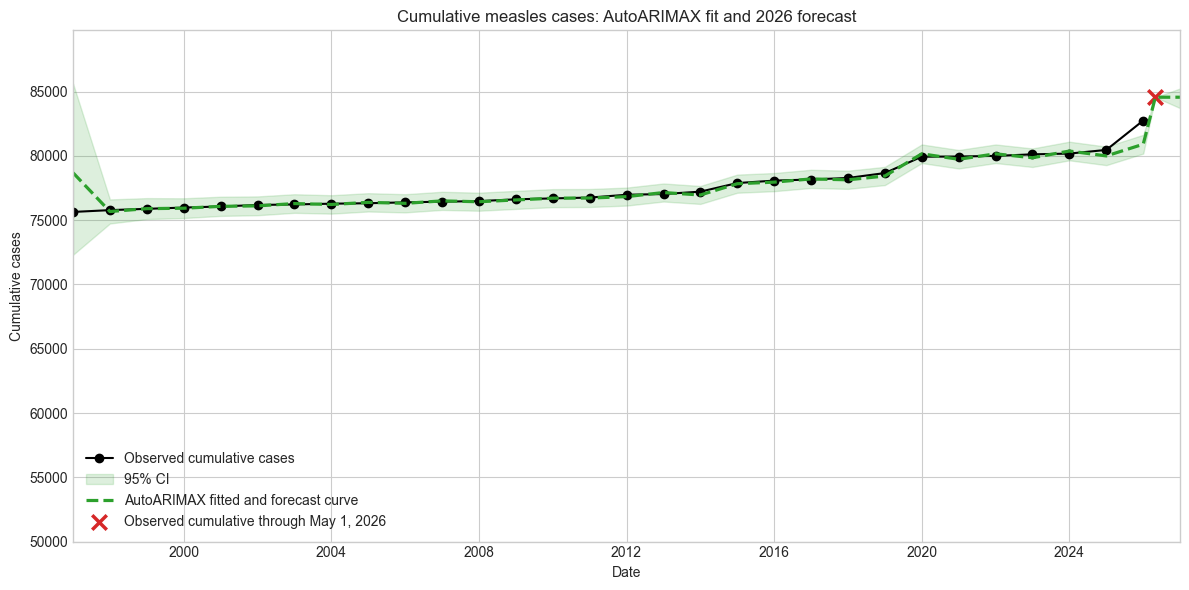

Saved autoarimax_model_summary.csv
Saved autoarimax_parameter_uncertainty.csv
Saved autoarimax_fitted_values.csv
Saved autoarimax_cumulative_forecast.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

historical_complete = all_data[all_data["count_year"] < FORECAST_COUNT_YEAR].copy()
model_curve = pd.concat([
    fitted_values["autoarimax_fitted_cumulative_cases"],
    pd.Series(
        [partial_2026_cumulative, forecast_cumulative_cases[0]],
        index=[PARTIAL_2026_DATE, FULL_YEAR_2026_FORECAST_DATE],
        name="autoarimax_curve",
    ),
]).sort_index()
ci_lower_curve = pd.concat([
    fitted_values["ci_lower_95"],
    pd.Series(
        [partial_2026_cumulative, forecast_ci[0, 0]],
        index=[PARTIAL_2026_DATE, FULL_YEAR_2026_FORECAST_DATE],
        name="ci_lower_95",
    ),
]).sort_index()
ci_upper_curve = pd.concat([
    fitted_values["ci_upper_95"],
    pd.Series(
        [partial_2026_cumulative, forecast_ci[0, 1]],
        index=[PARTIAL_2026_DATE, FULL_YEAR_2026_FORECAST_DATE],
        name="ci_upper_95",
    ),
]).sort_index()

ax.plot(
    historical_complete.index,
    historical_complete["cumulative_cases"],
    marker="o",
    color="black",
    label="Observed cumulative cases",
)
ax.fill_between(
    model_curve.index,
    ci_lower_curve,
    ci_upper_curve,
    color="tab:green",
    alpha=0.16,
    label="95% CI",
)
ax.plot(
    model_curve.index,
    model_curve,
    color="tab:green",
    linestyle="--",
    linewidth=2.3,
    label="AutoARIMAX fitted and forecast curve",
)
ax.scatter(
    [PARTIAL_2026_DATE],
    [partial_2026_cumulative],
    color="tab:red",
    marker="x",
    s=110,
    linewidths=2.5,
    label="Observed cumulative through May 1, 2026",
)

ax.set_xlim(fitted_values.index.min(), FULL_YEAR_2026_FORECAST_DATE)
ax.set_ylim(bottom=50000)
ax.set_title("Cumulative measles cases: AutoARIMAX fit and 2026 forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative cases")
ax.legend()
plt.tight_layout()
plt.savefig("autoarimax_cumulative_forecast.png", dpi=300)
plt.show()

model_summary.to_csv("autoarimax_model_summary.csv", index=False)
param_uncertainty.to_csv("autoarimax_parameter_uncertainty.csv", index_label="parameter")
fitted_values.to_csv("autoarimax_fitted_values.csv")

print("Saved autoarimax_model_summary.csv")
print("Saved autoarimax_parameter_uncertainty.csv")
print("Saved autoarimax_fitted_values.csv")
print("Saved autoarimax_cumulative_forecast.png")


## Terminal Review

```bash
column -s, -t < autoarimax_model_summary.csv
column -s, -t < autoarimax_parameter_uncertainty.csv
```
